# Imports


In [13]:
import kagglehub
import os
import pandas as pd
from pathlib import Path
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt

# Data

In [3]:
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\ellipticco\elliptic-data-set\versions\1


In [4]:
dir_path = Path(path) / "elliptic_bitcoin_dataset"

classes_path = dir_path / "elliptic_txs_classes.csv"
edgelist_path = dir_path / "elliptic_txs_edgelist.csv"
features_path = dir_path / "elliptic_txs_features.csv"

df_classes = pd.read_csv(classes_path)
df_edgelist = pd.read_csv(edgelist_path)
df_features = pd.read_csv(features_path, header=None)

In [5]:
df_classes

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown
...,...,...
203764,173077460,unknown
203765,158577750,unknown
203766,158375402,1
203767,158654197,unknown


In [6]:
df_edgelist

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [7]:
df_features

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.162722,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.261246,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.397749,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399


# Data processing

### Merge DataFrames

In [8]:
df_features.columns = ["txId", "time_step"] + [f"feature_{i}" for i in range(1, len(df_features.columns) - 1)]
df = pd.merge(df_features, df_classes, on="txId")
df

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown


### Class mask

In [9]:
df["label"] = df["class"].map({"1": 1, "2": 0, "unknown": -1})
df["labeled_mask"] = df["label"] != -1

df

C:\Users\Dell\AppData\Local\Temp\ipykernel_14748\3987237647.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["class"].map({"1": 1, "2": 0, "unknown": -1})
C:\Users\Dell\AppData\Local\Temp\ipykernel_14748\3987237647.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["labeled_mask"] = df["label"] != -1


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,label,labeled_mask
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,-1,False
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2,0,True
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,-1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1,False
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown,-1,False
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1,1,True
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown,-1,False


### Converting edge ID to 0 - N-1 ragne

In [10]:
mapping = {idx: i for i, idx in enumerate(df["txId"].values)}

df_edgelist["txId1"] = df_edgelist["txId1"].map(mapping)
df_edgelist["txId2"] = df_edgelist["txId2"].map(mapping)

df_edgelist

,txId1,txId2
0,0,1
1,2,3
2,4,5
3,6,7
4,8,9
...,...,...
234350,203602,201430
234351,203603,203099
234352,201921,202042
234353,201480,201368


### Create Data Object

In [11]:
edge_index = torch.tensor(df_edgelist[["txId1", "txId2"]].values.T, dtype=torch.long)
feature_cols = [f"feature_{i}" for i in range(1, 166)]

x = torch.tensor(df[feature_cols].values, dtype=torch.float)
y = torch.tensor(df["label"].values, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

### Train-Test Split

In [12]:
time_steps = df["time_step"].values
is_known = df["labeled_mask"].values

train_mask = (time_steps <= 34) & is_known
test_mask = (time_steps > 34) & is_known

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

# Data visualization

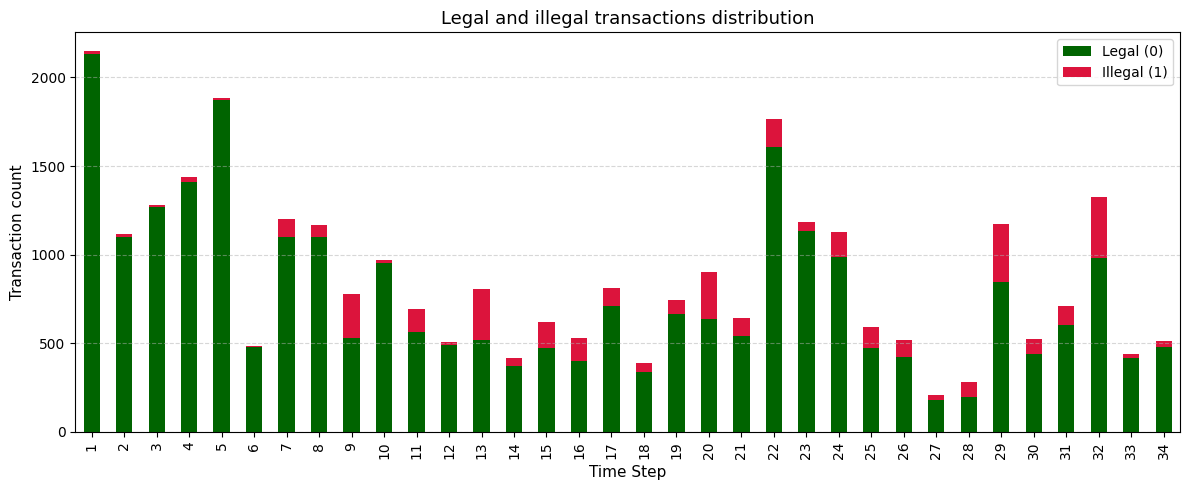

In [16]:
df_train_plot = df[(df["time_step"] <= 34) & (df["labeled_mask"] == True)]

grouped_train = df_train_plot.groupby(["time_step", "label"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
grouped_train.plot(kind="bar", stacked=True, ax=plt.gca(), color=["darkgreen", "crimson"])

plt.title("Legal and illegal transactions distribution", fontsize=13)
plt.xlabel("Time Step", fontsize=11)
plt.ylabel("Transaction count", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["Legal (0)", "Illegal (1)"])

plt.tight_layout()
plt.show()